# Digital Signal Processing - Session 5

## Plot the Graph of $|X(z)|$ for the z-transform

Plot the graph of $|X(z)|$ for the z-transform

$$
X(z) = \frac{z^{-1} - z^{-2}}{1 - 1.2732z^{-1} + 0.81z^{-2}}
= \frac{z - 1}{z^2 - 1.2732z + 0.81}
$$

which has one zero at $z_1 = 1$ and two poles at $p_1 = 0.9e^{j π/4}, p_2 = 0.9e^{-j π/4}$.

Note the high peaks near the singularities (poles) and the deep valley close to the zero.

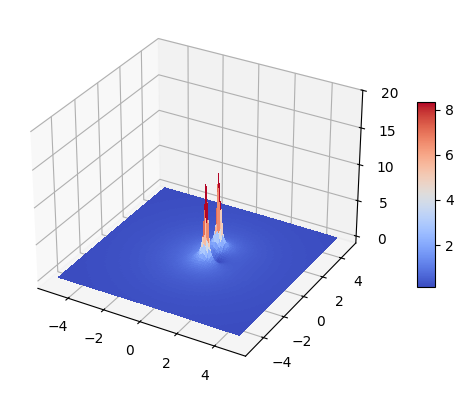

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cm

# set up a figure twice as wide as it is tall
fig = plt.figure(figsize=plt.figaspect(0.5))

# set up the Axes for the first plot
ax = fig.add_subplot(1, 1, 1, projection='3d')
# plot a 3D surface like in the example mplot3d/surface3d_demo
X = np.arange(-5, 5, 0.1)
Y = np.arange(-5, 5, 0.1)
X, Y = np.meshgrid(X, Y)
H = X+Y*1j
Z = np.abs((H**-1-H**-2)/(1-1.2732*H**-1+0.81*H**-2))
surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_zlim(-1, 5)
fig.colorbar(surf, shrink=0.5, aspect=10)

## Example: 3-point moving average (FIR)

Determine $h[n]$ of this system:

$$
y[n] = \frac{1}{3}(x[n] + x[n-1] + x[n-2])
$$

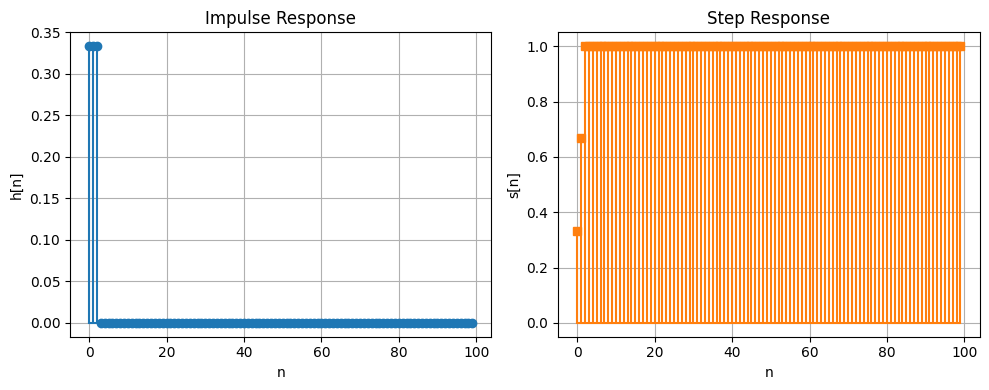

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Moving Average (length = 3)
num = [1/3, 1/3, 1/3]  # numerator
den = [1, 0, 0]        # denominator padded

# Impulse response
t, h = signal.dimpulse((num, den, 1))
h = np.squeeze(h)

# Step response
t, s = signal.dstep((num, den, 1))
s = np.squeeze(s)

# Plot impulse and step response
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

# Impulse response
ax1.stem(t, h, linefmt='C0-', markerfmt='C0o', basefmt='C0-')
ax1.set_title("Impulse Response")
ax1.set_xlabel("n")
ax1.set_ylabel("h[n]")
ax1.grid(True)

# Step response
ax2.stem(t, s, linefmt='C1-', markerfmt='C1s', basefmt='C1-')
ax2.set_title("Step Response")
ax2.set_xlabel("n")
ax2.set_ylabel("s[n]")
ax2.grid(True)

plt.tight_layout()
plt.show()

## Pole-Zero Plot

Sketch the pole-zero plot of this system:

$$
H(z) = \frac{1 - 0.5 z^-1}{1 - 0.7 z^-1 - z^-2}
$$

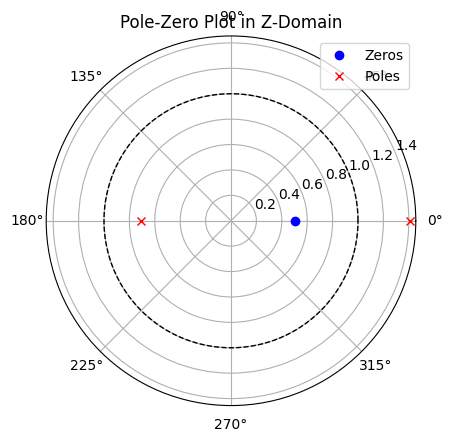

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Example system: H(z) = (1 - 0.5 z^-1) / (1 - 0.7 z^-1 - z^-2)
num = [1, -0.5]
den = [1, -0.7, -1]

# Get zeros, poles, gain
z, p, _ = signal.tf2zpk(num, den) # transfer to pole-zero plot

zeros_r, zeros_theta = np.abs(z), np.angle(z)
poles_r, poles_theta = np.abs(p), np.angle(p)

# Draw unit circle
theta = np.linspace(0, 2*np.pi, 400)
plt.polar(theta, np.ones_like(theta), 'k--', linewidth=1)

plt.polar(zeros_theta, zeros_r, 'bo', label="Zeros")
plt.polar(poles_theta, poles_r, 'rx', label="Poles")

plt.title("Pole-Zero Plot in Z-Domain")
plt.legend(loc="upper right")
plt.show()

**Remark**

This system is not BIBO stable as there exists a pole that lies outside the unit circle.